# 02 - Building Qwen3-1.7B From Scratch

**Goal:** Build the full Qwen3-1.7B architecture by hand, load real pretrained weights, and generate text.

**Prerequisites:** [Basics AI.ipynb](Basics%20AI.ipynb) (GPT-2 from scratch), [01-qwen3-overview.ipynb](01-qwen3-overview.ipynb) (Qwen3 model family survey)

### What's New vs GPT-2

| Aspect | GPT-2 (Basics AI) | Qwen3 (This Notebook) |
|--------|-------------------|-----------------------|
| Position encoding | Learned absolute (`nn.Embedding`) | **RoPE** — rotation applied to Q,K inside attention |
| Normalization | LayerNorm ($\gamma, \beta$, mean subtraction) | **RMSNorm** ($\gamma$ only, no mean, no bias) |
| FFN | Linear $\to$ GELU $\to$ Linear, 4x expand | **SwiGLU**: gate + up + down projections, SiLU, 3x expand |
| Attention | MHA (12 Q = 12 KV) | **GQA** (12 Q heads, 4 KV heads) |
| Attention extra | None | **QK-Norm** — RMSNorm on Q,K per-head before RoPE |
| Bias | Everywhere | **None** |
| Weight format | Conv1D (needs `.T`) | Standard `nn.Linear` (no transpose!) |

In [13]:
import sys
sys.path.insert(0, "..")

import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForCausalLM
from src.utils import get_device, print_model_summary, format_param_count

device = get_device()
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

# --- Qwen3-1.7B Config (hard-coded for clarity) ---
vocab_size        = 151_936
d_model           = 1536         # hidden_size
n_layer           = 28           # num_hidden_layers
num_heads         = 12           # num_attention_heads (Q heads)
num_kv_heads      = 4            # num_key_value_heads (K, V heads for GQA)
head_dim          = 128          # explicit head_dim (NOT d_model // num_heads!)
intermediate_size = 4608         # FFN intermediate (3x d_model for SwiGLU)
max_seq_len       = 40_960       # max_position_embeddings
rope_theta        = 1_000_000.0  # RoPE base frequency
rms_norm_eps      = 1e-6         # RMSNorm epsilon

# Derived
num_kv_groups = num_heads // num_kv_heads  # 12 // 4 = 3 (each KV head serves 3 Q heads)

# NOTE: head_dim=128, so d_model = num_heads * head_dim = 12 * 128 = 1536. Checks out.
# But KV projection size = num_kv_heads * head_dim = 4 * 128 = 512. Much smaller!

text = "The Transformer architecture is important because"
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen3-1.7B")
tokens = tokenizer(text, return_tensors="pt")
input_ids = tokens["input_ids"]    # (1, T)
T = input_ids.shape[1]

print(f'Input: "{text}"')
print(f"Token IDs shape: {input_ids.shape}")
print(f"Sequence length T = {T}")
print(f"Token IDs: {input_ids}")

Using device: mps
PyTorch version: 2.10.0
Input: "The Transformer architecture is important because"
Token IDs shape: torch.Size([1, 6])
Sequence length T = 6
Token IDs: tensor([[  785, 62379, 17646,   374,  2989,  1576]])


## 1 Token Embedding

Same as GPT-2 — integer IDs to dense float vectors via a learnable lookup table. But unlike GPT-2, there is **no positional embedding table**. Qwen3 uses RoPE (Section 3) which is applied later, inside the attention mechanism.

### Math

$$W_E \in \mathbb{R}^{|V| \times d_{\text{model}}}$$

$$\mathbf{x}_{\text{embed}} = W_E[\text{token\_ids}]$$

> Output shape: $(B, T, d_{\text{model}})$ — with $|V| = 151{,}936$ and $d_{\text{model}} = 1536$

In [14]:
# Token Embedding Layer
class TokenEmbedding(nn.Module):
    def __init__(self, vocab_size, d_model):          # (151936, 1536)
        super(TokenEmbedding, self).__init__()
        self.W_E = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=d_model
        )

    def forward(self, input_ids):
        return self.W_E(input_ids)                    # (B, T, d_model)

tok_emb = TokenEmbedding(vocab_size=vocab_size, d_model=d_model)
test_out = tok_emb(input_ids)
print(f"Token embedding output: {test_out.shape}")    # (1, T, 1536)

Token embedding output: torch.Size([1, 6, 1536])


## 2 RMSNorm (Replacing LayerNorm)

Qwen3 uses **RMSNorm** instead of LayerNorm. Simpler and cheaper — no mean subtraction, no learned bias ($\beta$). Only a learned scale ($\gamma$).

### Math

$$\text{RMSNorm}(\mathbf{x}) = \gamma \cdot \frac{\mathbf{x}}{\text{RMS}(\mathbf{x}) + \epsilon}$$

where:

$$\text{RMS}(\mathbf{x}) = \sqrt{\frac{1}{d}\sum_{i=1}^{d} x_i^2}$$

Equivalently (as implemented):

$$\text{RMSNorm}(\mathbf{x}) = \gamma \cdot \mathbf{x} \cdot \text{rsqrt}\!\left(\frac{1}{d}\sum_{i=1}^{d} x_i^2 + \epsilon\right)$$

### Comparison

| Property | LayerNorm (GPT-2) | RMSNorm (Qwen3) |
|----------|-------------------|------------------|
| Mean subtraction | Yes ($x - \mu$) | No |
| Learnable scale ($\gamma$) | Yes | Yes |
| Learnable bias ($\beta$) | Yes | **No** |
| Parameters per layer | $2d$ | $d$ |

> Output still: $(B, T, d_{\text{model}})$

In [15]:
class RMSNorm(nn.Module):
    def __init__(self, d_model, eps=1e-6):
        super(RMSNorm, self).__init__()
        self.weight = nn.Parameter(torch.ones(d_model))   # gamma, initialized to 1
        self.eps = eps

    def forward(self, x):
        # Cast to float32 for numerical stability, then cast back
        input_dtype = x.dtype
        x = x.to(torch.float32)
        variance = x.pow(2).mean(-1, keepdim=True)        # (B, T, 1)
        x = x * torch.rsqrt(variance + self.eps)           # (B, T, d_model)
        return (self.weight * x).to(input_dtype)            # (B, T, d_model)

# Test
rms_norm = RMSNorm(d_model=d_model, eps=rms_norm_eps)
norm_out = rms_norm(test_out)
print(f"RMSNorm output: {norm_out.shape}")                 # (1, T, 1536)
print(f"Learnable params: {sum(p.numel() for p in rms_norm.parameters())}")  # 1536 (just gamma)

RMSNorm output: torch.Size([1, 6, 1536])
Learnable params: 1536


## 3 Rotary Position Embeddings (RoPE)

Instead of *adding* a position vector (GPT-2), RoPE *rotates* the query and key vectors by position-dependent angles. The key insight: the dot product between rotated Q and K depends only on their **relative distance**, not absolute position.

### Step 1 — Frequency Computation

For each dimension pair $i = 0, 1, \ldots, d/2 - 1$:

$$\theta_i = \frac{1}{\text{base}^{\,2i/d}}$$

where $\text{base} = 1{,}000{,}000$ (Qwen3) and $d = d_{\text{head}} = 128$.

### Step 2 — Position-Dependent Angles

For position $m$, the rotation angle for dimension pair $i$:

$$\Theta_m = [m\theta_0, \; m\theta_1, \; \ldots, \; m\theta_{d/2-1}]$$

### Step 3 — Apply Rotation (Complex Number Intuition)

Treat each dimension pair $(x_{2i}, x_{2i+1})$ as a complex number $x_{2i} + j \cdot x_{2i+1}$:

$$(x_{2i} + j \cdot x_{2i+1}) \cdot e^{j \cdot m\theta_i}$$

Expanding with Euler's formula:

$$= (x_{2i}\cos(m\theta_i) - x_{2i+1}\sin(m\theta_i)) + j(x_{2i}\sin(m\theta_i) + x_{2i+1}\cos(m\theta_i))$$

### Implementation (the "rotate_half" trick)

$$\text{RoPE}(\mathbf{x}, m) = \mathbf{x} \odot \cos(\Theta_m) + \text{rotate\_half}(\mathbf{x}) \odot \sin(\Theta_m)$$

where $\text{rotate\_half}([x_0, \ldots, x_{d/2-1}, \; x_{d/2}, \ldots, x_{d-1}]) = [-x_{d/2}, \ldots, -x_{d-1}, \; x_0, \ldots, x_{d/2-1}]$

### Why It Gives Relative Position

$$\langle \text{RoPE}(\mathbf{q}, m), \; \text{RoPE}(\mathbf{k}, n) \rangle \; \text{depends only on } m - n$$

The rotations "cancel out" in the dot product, leaving only the relative distance.

> Applied to **Q and K only** (not V). Computed once, reused across all layers.

In [16]:
class RotaryEmbedding(nn.Module):
    def __init__(self, head_dim, max_seq_len, rope_theta=1_000_000.0):
        super(RotaryEmbedding, self).__init__()
        # Step 1: Compute inverse frequencies  theta_i = 1 / (base^(2i/d))
        inv_freq = 1.0 / (
            rope_theta ** (torch.arange(0, head_dim, 2, dtype=torch.float32) / head_dim)
        )                                                       # (head_dim/2,) = (64,)
        self.register_buffer("inv_freq", inv_freq, persistent=False)

    def forward(self, x, position_ids):
        # x: any tensor, used only for device/dtype
        # position_ids: (B, T) integer positions

        # inv_freq: (head_dim/2,) -> (B, head_dim/2, 1)
        inv_freq_expanded = self.inv_freq[None, :, None].float().expand(
            position_ids.shape[0], -1, 1
        ).to(x.device)                                          # (B, 64, 1)

        # position_ids: (B, T) -> (B, 1, T)
        position_ids_expanded = position_ids[:, None, :].float()  # (B, 1, T)

        # Step 2: m * theta for all positions and all freq dimensions
        # (B, 64, 1) @ (B, 1, T) -> (B, 64, T) -> transpose -> (B, T, 64)
        freqs = (inv_freq_expanded @ position_ids_expanded).transpose(1, 2)

        # Duplicate to cover full head_dim: [theta_0..theta_63, theta_0..theta_63]
        emb = torch.cat((freqs, freqs), dim=-1)                  # (B, T, 128)
        cos = emb.cos()                                           # (B, T, head_dim)
        sin = emb.sin()                                           # (B, T, head_dim)
        return cos.to(dtype=x.dtype), sin.to(dtype=x.dtype)

rotary_emb = RotaryEmbedding(head_dim=head_dim, max_seq_len=max_seq_len, rope_theta=rope_theta)
position_ids = torch.arange(T).unsqueeze(0)                      # (1, T)
cos, sin = rotary_emb(test_out, position_ids)
print(f"cos shape: {cos.shape}")                                  # (1, T, 128)
print(f"sin shape: {sin.shape}")                                  # (1, T, 128)

cos shape: torch.Size([1, 6, 128])
sin shape: torch.Size([1, 6, 128])


In [17]:
def rotate_half(x):
    """Swap and negate halves: [x1, x2] -> [-x2, x1]"""
    x1 = x[..., : x.shape[-1] // 2]                            # first half
    x2 = x[..., x.shape[-1] // 2 :]                            # second half
    return torch.cat((-x2, x1), dim=-1)


def apply_rotary_pos_emb(q, k, cos, sin):
    """Apply RoPE to query and key tensors.

    q: (B, num_heads, T, head_dim)
    k: (B, num_kv_heads, T, head_dim)
    cos, sin: (B, T, head_dim) -> unsqueeze to (B, 1, T, head_dim) for broadcasting
    """
    cos = cos.unsqueeze(1)                                      # (B, 1, T, head_dim)
    sin = sin.unsqueeze(1)                                      # (B, 1, T, head_dim)
    q_embed = (q * cos) + (rotate_half(q) * sin)                # (B, num_heads, T, head_dim)
    k_embed = (k * cos) + (rotate_half(k) * sin)                # (B, num_kv_heads, T, head_dim)
    return q_embed, k_embed

# Quick test: rotate_half swaps and negates
test_vec = torch.tensor([1.0, 2.0, 3.0, 4.0])
print(f"rotate_half({test_vec.tolist()}) = {rotate_half(test_vec).tolist()}")
# Expected: [-3.0, -4.0, 1.0, 2.0]

rotate_half([1.0, 2.0, 3.0, 4.0]) = [-3.0, -4.0, 1.0, 2.0]


### Visualizing RoPE Frequencies

How do the rotation angles change across dimensions and positions? Low-index dimension pairs rotate fast (high frequency) — they encode **local** position differences. High-index pairs rotate slowly — they encode **long-range** dependencies. The heatmap shows the full rotation pattern.

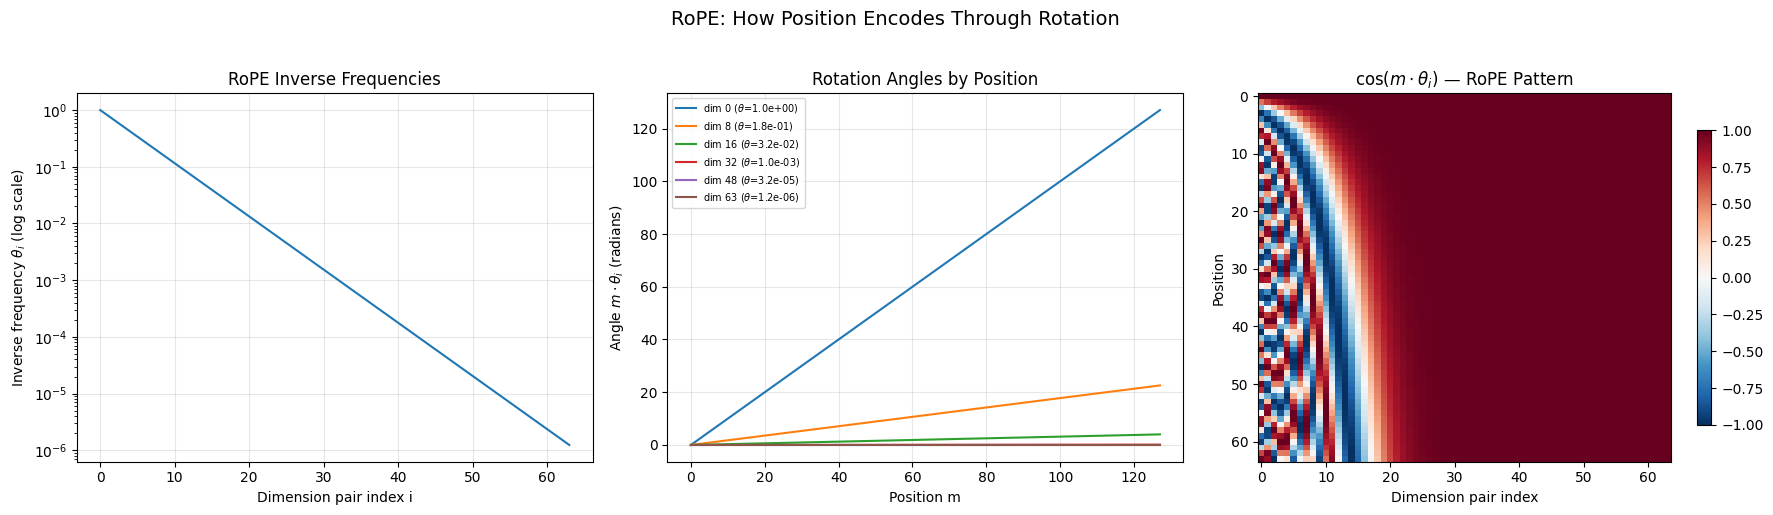

Low dim pairs (left) -> high frequency -> local position patterns
High dim pairs (right) -> low frequency -> long-range dependencies


In [18]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Inverse frequencies (theta_i) across dimension pairs — log scale
inv_freq_viz = 1.0 / (rope_theta ** (torch.arange(0, head_dim, 2, dtype=torch.float32) / head_dim))
axes[0].semilogy(inv_freq_viz.numpy())
axes[0].set_xlabel("Dimension pair index i")
axes[0].set_ylabel("Inverse frequency $\\theta_i$ (log scale)")
axes[0].set_title("RoPE Inverse Frequencies")
axes[0].grid(True, alpha=0.3)

# 2. Rotation angles for selected dimension pairs across positions
positions_viz = torch.arange(128).float()
for d in [0, 8, 16, 32, 48, 63]:
    angles = (positions_viz * inv_freq_viz[d]).numpy()
    axes[1].plot(angles, label=f"dim {d} ($\\theta$={inv_freq_viz[d]:.1e})")
axes[1].set_xlabel("Position m")
axes[1].set_ylabel("Angle $m \\cdot \\theta_i$ (radians)")
axes[1].set_title("Rotation Angles by Position")
axes[1].legend(fontsize=7)
axes[1].grid(True, alpha=0.3)

# 3. Heatmap: cos(m * theta_i) for first 64 positions x all 64 dimension pairs
pos_range = torch.arange(64).float()
angle_grid = pos_range[:, None] * inv_freq_viz[None, :]   # (64, 64)
im = axes[2].imshow(torch.cos(angle_grid).numpy(), aspect="auto", cmap="RdBu_r", vmin=-1, vmax=1)
axes[2].set_xlabel("Dimension pair index")
axes[2].set_ylabel("Position")
axes[2].set_title("$\\cos(m \\cdot \\theta_i)$ — RoPE Pattern")
plt.colorbar(im, ax=axes[2], shrink=0.8)

plt.suptitle("RoPE: How Position Encodes Through Rotation", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("Low dim pairs (left) -> high frequency -> local position patterns")
print("High dim pairs (right) -> low frequency -> long-range dependencies")

## 4 SwiGLU MLP (Replacing GELU MLP)

Qwen3 uses **SwiGLU** — a gated feed-forward with **3 linear layers** instead of 2. One projection acts as a "gate" that controls information flow.

### Math

GPT-2 MLP (2 projections):

$$\text{MLP}_{\text{GPT-2}}(\mathbf{x}) = W_2 \cdot \text{GELU}(W_1 \mathbf{x} + b_1) + b_2$$

Qwen3 SwiGLU (3 projections, no bias):

$$\text{SwiGLU}(\mathbf{x}) = W_{\text{down}} \cdot \bigl(\text{SiLU}(W_{\text{gate}} \mathbf{x}) \odot W_{\text{up}} \mathbf{x}\bigr)$$

where SiLU (Sigmoid Linear Unit, also called "swish"):

$$\text{SiLU}(x) = x \cdot \sigma(x) = \frac{x}{1 + e^{-x}}$$

### Comparison

| Property | GPT-2 MLP | Qwen3 SwiGLU |
|----------|-----------|--------------|
| Linear layers | 2 ($W_1$, $W_2$) | 3 ($W_{\text{gate}}$, $W_{\text{up}}$, $W_{\text{down}}$) |
| Expansion factor | 4x ($768 \to 3072$) | 3x ($1536 \to 4608$) |
| Activation | GELU | SiLU (applied only to gate) |
| Gating | None | Yes ($\text{gate} \odot \text{up}$) |
| Biases | Yes | **No** |

> Why 3x instead of 4x? SwiGLU uses three projections, so to keep roughly the same parameter budget, the expansion factor is reduced. $4608 / 1536 = 3$.

In [19]:
class SwiGLUMLP(nn.Module):
    def __init__(self, d_model, intermediate_size):      # (1536, 4608)
        super(SwiGLUMLP, self).__init__()
        self.gate_proj = nn.Linear(d_model, intermediate_size, bias=False)  # (1536 -> 4608)
        self.up_proj   = nn.Linear(d_model, intermediate_size, bias=False)  # (1536 -> 4608)
        self.down_proj = nn.Linear(intermediate_size, d_model, bias=False)  # (4608 -> 1536)

    def forward(self, x):
        # SwiGLU: down_proj( silu(gate_proj(x)) * up_proj(x) )
        gate = F.silu(self.gate_proj(x))                # (B, T, intermediate_size)
        up   = self.up_proj(x)                           # (B, T, intermediate_size)
        return self.down_proj(gate * up)                 # (B, T, d_model)

# Test
mlp = SwiGLUMLP(d_model=d_model, intermediate_size=intermediate_size)
mlp_out = mlp(norm_out)
print(f"SwiGLU MLP output: {mlp_out.shape}")             # (1, T, 1536)

SwiGLU MLP output: torch.Size([1, 6, 1536])


## 5 Grouped Query Attention (GQA)

The core of Qwen3's attention. Unlike GPT-2's MHA where every head has its own Q, K, V, **GQA shares K and V heads** across groups of Q heads. This saves memory (smaller KV cache) with minimal quality loss.

### Head Grouping

```
Q heads:  Q0  Q1  Q2 | Q3  Q4  Q5 | Q6  Q7  Q8 | Q9  Q10 Q11
               |           |            |              |
KV heads:     KV0         KV1          KV2            KV3

Each KV head is shared by 3 Q heads (num_kv_groups = 12 / 4 = 3)
```

### Math

**Projections** (note K, V are smaller!):

$$Q = xW_Q \in \mathbb{R}^{B \times T \times (H_Q \cdot d_k)}, \quad W_Q \in \mathbb{R}^{d \times (H_Q \cdot d_k)}$$

$$K = xW_K \in \mathbb{R}^{B \times T \times (H_{KV} \cdot d_k)}, \quad W_K \in \mathbb{R}^{d \times (H_{KV} \cdot d_k)}$$

$$V = xW_V \in \mathbb{R}^{B \times T \times (H_{KV} \cdot d_k)}, \quad W_V \in \mathbb{R}^{d \times (H_{KV} \cdot d_k)}$$

where $H_Q = 12$, $H_{KV} = 4$, $d_k = 128$.

**Attention** (after expanding K, V to match Q heads):

$$\text{Attn}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right)V$$

### QK-Norm (Qwen3-Specific)

Before applying RoPE, Qwen3 normalizes Q and K per-head with RMSNorm. This stabilizes attention logits in deep networks:

$$Q_h \leftarrow \text{RMSNorm}(Q_h), \quad K_g \leftarrow \text{RMSNorm}(K_g)$$

### Forward Pass Order

$$\text{project} \to \text{reshape} \to \text{QK-Norm} \to \text{transpose} \to \text{RoPE} \to \text{repeat\_kv} \to \text{attention} \to \text{concat} \to W_O$$

> K, V projection is $[d, H_{KV} \cdot d_k] = [1536, 512]$ — much smaller than Q's $[1536, 1536]$.

In [20]:
def repeat_kv(hidden_states, n_rep):
    """Repeat KV heads to match the number of Q heads.

    Input:  (B, num_kv_heads, T, head_dim)  e.g. (B, 4, T, 128)
    Output: (B, num_heads, T, head_dim)     e.g. (B, 12, T, 128)
    """
    if n_rep == 1:
        return hidden_states
    B, num_kv_heads, T, hd = hidden_states.shape
    # (B, 4, 1, T, 128) -> expand -> (B, 4, 3, T, 128) -> reshape -> (B, 12, T, 128)
    hidden_states = hidden_states[:, :, None, :, :].expand(
        B, num_kv_heads, n_rep, T, hd
    )
    return hidden_states.reshape(B, num_kv_heads * n_rep, T, hd)

# Test: 4 KV heads -> 12 Q heads
test_kv = torch.randn(1, 4, 5, 128)
expanded = repeat_kv(test_kv, n_rep=3)
print(f"repeat_kv: {test_kv.shape} -> {expanded.shape}")  # (1, 4, 5, 128) -> (1, 12, 5, 128)

repeat_kv: torch.Size([1, 4, 5, 128]) -> torch.Size([1, 12, 5, 128])


In [21]:
class GroupedQueryAttention(nn.Module):
    def __init__(self, d_model, num_heads, num_kv_heads, head_dim, rms_norm_eps=1e-6):
        super(GroupedQueryAttention, self).__init__()
        self.num_heads = num_heads              # 12 (Q heads)
        self.num_kv_heads = num_kv_heads        # 4  (KV heads)
        self.head_dim = head_dim                # 128
        self.num_kv_groups = num_heads // num_kv_heads  # 3
        self.scaling = head_dim ** -0.5         # 1/sqrt(128)

        # Q, K, V, O projections — no bias!
        self.q_proj = nn.Linear(d_model, num_heads * head_dim, bias=False)      # (1536, 1536)
        self.k_proj = nn.Linear(d_model, num_kv_heads * head_dim, bias=False)   # (1536, 512)
        self.v_proj = nn.Linear(d_model, num_kv_heads * head_dim, bias=False)   # (1536, 512)
        self.o_proj = nn.Linear(num_heads * head_dim, d_model, bias=False)      # (1536, 1536)

        # QK-Norm: RMSNorm on each head's dimension (Qwen3-specific!)
        self.q_norm = RMSNorm(head_dim, eps=rms_norm_eps)     # normalizes (128,)
        self.k_norm = RMSNorm(head_dim, eps=rms_norm_eps)     # normalizes (128,)

    def forward(self, x, cos, sin, return_attn_weights=False):
        B, T, _ = x.shape

        # Step 1: Project to Q, K, V
        q = self.q_proj(x)                           # (B, T, num_heads * head_dim) = (B, T, 1536)
        k = self.k_proj(x)                           # (B, T, num_kv_heads * head_dim) = (B, T, 512)
        v = self.v_proj(x)                           # (B, T, num_kv_heads * head_dim) = (B, T, 512)

        # Step 2: Reshape to multi-head format
        q = q.view(B, T, self.num_heads, self.head_dim)       # (B, T, 12, 128)
        k = k.view(B, T, self.num_kv_heads, self.head_dim)    # (B, T, 4, 128)
        v = v.view(B, T, self.num_kv_heads, self.head_dim)    # (B, T, 4, 128)

        # Step 3: QK-Norm (Qwen3-specific!) — normalize BEFORE RoPE
        q = self.q_norm(q)                           # (B, T, 12, 128) — norm on last dim
        k = self.k_norm(k)                           # (B, T, 4, 128)

        # Step 4: Transpose to (B, heads, T, head_dim) for attention
        q = q.transpose(1, 2)                        # (B, 12, T, 128)
        k = k.transpose(1, 2)                        # (B, 4, T, 128)
        v = v.transpose(1, 2)                        # (B, 4, T, 128)

        # Step 5: Apply RoPE to Q and K (NOT V!)
        q, k = apply_rotary_pos_emb(q, k, cos, sin)

        # Step 6: Expand KV heads to match Q heads (GQA)
        k = repeat_kv(k, self.num_kv_groups)         # (B, 4, T, 128) -> (B, 12, T, 128)
        v = repeat_kv(v, self.num_kv_groups)         # (B, 4, T, 128) -> (B, 12, T, 128)

        # Step 7: Scaled dot-product attention with causal mask
        # Q @ K^T: (B, 12, T, 128) @ (B, 12, 128, T) -> (B, 12, T, T)
        attn_weights = torch.matmul(q, k.transpose(2, 3)) * self.scaling

        # Causal mask: prevent attending to future tokens
        causal_mask = torch.triu(
            torch.full((T, T), float("-inf"), device=x.device), diagonal=1
        )                                              # (T, T) upper triangular = -inf
        attn_weights = attn_weights + causal_mask      # broadcast: (B, 12, T, T)

        # Softmax in float32 for stability
        attn_weights = F.softmax(attn_weights, dim=-1, dtype=torch.float32).to(q.dtype)

        # Step 8: Weighted sum of values
        attn_output = torch.matmul(attn_weights, v)   # (B, 12, T, 128)

        # Step 9: Concatenate heads and project
        attn_output = attn_output.transpose(1, 2).contiguous()  # (B, T, 12, 128)
        attn_output = attn_output.reshape(B, T, -1)             # (B, T, 1536)
        output = self.o_proj(attn_output)                        # (B, T, 1536)

        if return_attn_weights:
            return output, attn_weights                # attn_weights: (B, num_heads, T, T)
        return output

# Test
gqa = GroupedQueryAttention(
    d_model=d_model, num_heads=num_heads,
    num_kv_heads=num_kv_heads, head_dim=head_dim,
    rms_norm_eps=rms_norm_eps
)
gqa_out = gqa(norm_out, cos, sin)
print(f"GQA output: {gqa_out.shape}")                  # (1, T, 1536)

GQA output: torch.Size([1, 6, 1536])


## 6 Transformer Block

Same pre-norm residual pattern as GPT-2, but with RMSNorm + GQA + SwiGLU:

$$\mathbf{h} = \mathbf{x} + \text{GQA}(\text{RMSNorm}_1(\mathbf{x}), \, \cos, \sin)$$

$$\mathbf{x'} = \mathbf{h} + \text{SwiGLU}(\text{RMSNorm}_2(\mathbf{h}))$$

> Qwen3-1.7B stacks **28** of these blocks.

In [22]:
class Qwen3Block(nn.Module):
    """One Qwen3 transformer block: RMSNorm -> GQA -> residual -> RMSNorm -> SwiGLU -> residual."""
    def __init__(self, d_model, num_heads, num_kv_heads, head_dim,
                 intermediate_size, rms_norm_eps=1e-6):
        super(Qwen3Block, self).__init__()
        self.input_layernorm = RMSNorm(d_model, eps=rms_norm_eps)
        self.self_attn = GroupedQueryAttention(
            d_model=d_model, num_heads=num_heads,
            num_kv_heads=num_kv_heads, head_dim=head_dim,
            rms_norm_eps=rms_norm_eps
        )
        self.post_attention_layernorm = RMSNorm(d_model, eps=rms_norm_eps)
        self.mlp = SwiGLUMLP(d_model=d_model, intermediate_size=intermediate_size)

    def forward(self, x, cos, sin, return_intermediates=False):
        intermediates = {}

        # Sub-block 1: attention with residual
        residual = x
        if return_intermediates:
            intermediates["pre_norm"] = x.detach().float().norm(dim=-1).mean().item()
        x = self.input_layernorm(x)                     # (B, T, d_model)
        if return_intermediates:
            intermediates["post_input_norm"] = x.detach().float().norm(dim=-1).mean().item()

        attn_out = self.self_attn(x, cos, sin, return_attn_weights=return_intermediates)
        if return_intermediates:
            x, attn_weights = attn_out
            intermediates["attn_weights"] = attn_weights.detach()
        else:
            x = attn_out

        h = residual + x                                 # residual connection
        if return_intermediates:
            intermediates["post_attn_residual"] = h.detach().float().norm(dim=-1).mean().item()

        # Sub-block 2: MLP with residual
        residual = h
        h = self.post_attention_layernorm(h)              # (B, T, d_model)
        if return_intermediates:
            intermediates["post_mlp_norm"] = h.detach().float().norm(dim=-1).mean().item()
        h = self.mlp(h)                                   # (B, T, d_model)
        output = residual + h                              # (B, T, d_model)
        if return_intermediates:
            intermediates["post_mlp_residual"] = output.detach().float().norm(dim=-1).mean().item()

        if return_intermediates:
            return output, intermediates
        return output

# Test single block
block = Qwen3Block(
    d_model=d_model, num_heads=num_heads, num_kv_heads=num_kv_heads,
    head_dim=head_dim, intermediate_size=intermediate_size, rms_norm_eps=rms_norm_eps
)
block_out = block(test_out, cos, sin)
print(f"Qwen3Block output: {block_out.shape}")            # (1, T, 1536)

Qwen3Block output: torch.Size([1, 6, 1536])


## 7 Putting It All Together

The full forward pass:

$$\mathbf{x}_0 = W_E[\text{ids}]$$

$$(\cos, \sin) = \text{RoPE}(\text{positions})$$

$$\mathbf{x}_{i+1} = \text{Block}_i(\mathbf{x}_i, \cos, \sin) \quad \text{for } i = 0, \ldots, 27$$

$$\text{logits} = \text{RMSNorm}_f(\mathbf{x}_{28}) \cdot W_E^\top$$

Note the **weight tying** on the last line: the LM head reuses $W_E$ — the same matrix that embeds tokens is used to "unembed" them back to vocabulary logits.

In [23]:
class Qwen3ForCausalLM(nn.Module):
    """Full Qwen3-1.7B: embedding -> 28 blocks -> RMSNorm -> LM head (tied weights)."""
    def __init__(self, vocab_size, d_model, n_layer, num_heads, num_kv_heads,
                 head_dim, intermediate_size, max_seq_len, rope_theta, rms_norm_eps):
        super(Qwen3ForCausalLM, self).__init__()

        # Token embedding (no position embedding — RoPE handles that)
        self.embed_tokens = TokenEmbedding(vocab_size=vocab_size, d_model=d_model)

        # Rotary position embeddings
        self.rotary_emb = RotaryEmbedding(
            head_dim=head_dim, max_seq_len=max_seq_len, rope_theta=rope_theta
        )

        # 28 transformer blocks
        self.layers = nn.ModuleList([
            Qwen3Block(
                d_model=d_model, num_heads=num_heads,
                num_kv_heads=num_kv_heads, head_dim=head_dim,
                intermediate_size=intermediate_size, rms_norm_eps=rms_norm_eps
            )
            for _ in range(n_layer)
        ])

        # Final RMSNorm
        self.norm = RMSNorm(d_model, eps=rms_norm_eps)

        # LM head (weight-tied to embedding)
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)

    def forward(self, input_ids, return_intermediates=False):
        B, T = input_ids.shape
        position_ids = torch.arange(T, device=input_ids.device).unsqueeze(0)  # (1, T)

        # Token embeddings (no position add — RoPE is applied in attention)
        x = self.embed_tokens(input_ids)                      # (B, T, d_model)

        # Compute RoPE cos/sin for all positions
        cos, sin = self.rotary_emb(x, position_ids)           # (B, T, head_dim)

        # 28 transformer blocks
        all_intermediates = []
        for layer in self.layers:
            if return_intermediates:
                x, layer_intermediates = layer(x, cos, sin, return_intermediates=True)
                all_intermediates.append(layer_intermediates)
            else:
                x = layer(x, cos, sin)                        # (B, T, d_model)

        # Final norm + LM head
        x = self.norm(x)                                       # (B, T, d_model)
        logits = self.lm_head(x)                                # (B, T, vocab_size)

        if return_intermediates:
            return logits, all_intermediates
        return logits

model = Qwen3ForCausalLM(
    vocab_size=vocab_size, d_model=d_model, n_layer=n_layer,
    num_heads=num_heads, num_kv_heads=num_kv_heads,
    head_dim=head_dim, intermediate_size=intermediate_size,
    max_seq_len=max_seq_len, rope_theta=rope_theta,
    rms_norm_eps=rms_norm_eps
)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")
print(f"Formatted: {format_param_count(total_params)}")

Total parameters: 1,237,545,472
Formatted: 1.2B


### Visualizing Model Architecture

Full layer-by-layer breakdown with tensor shapes and parameter counts for every module in the model. This uses `torchinfo` to trace the forward pass and report the architecture summary.

## 8 Loading Pretrained Weights

Now the payoff — we copy real Qwen3-1.7B weights into our hand-built model.

### Key Differences from GPT-2 Weight Loading

| Aspect | GPT-2 | Qwen3 |
|--------|-------|-------|
| Weight format | Conv1D (need `.T`) | `nn.Linear` (**no transpose!**) |
| Bias terms | Yes (load bias for every layer) | **None** |
| Q, K, V | Packed into one `c_attn` matrix | **Separate** `q_proj`, `k_proj`, `v_proj` |
| Extra per layer | None | `q_norm.weight`, `k_norm.weight` (QK-Norm) |
| Weight tying | `lm_head = wte` | `lm_head = embed_tokens` |

> Much simpler than GPT-2 — no transpositions, no bias loading, no matrix unpacking.

In [24]:
def load_qwen3_weights(our_model):
    """Load pretrained Qwen3-1.7B weights into our hand-built model."""
    print("Loading HuggingFace model (downloads ~3.4GB on first run)...")
    hf_model = AutoModelForCausalLM.from_pretrained(
        "Qwen/Qwen3-1.7B",
        torch_dtype=torch.float32,    # float32 for weight copying
        device_map="cpu",             # load to CPU first
    )
    sd = hf_model.state_dict()
    print(f"HF model loaded. State dict keys: {len(sd)}")

    # Free HF model structure, keep only state dict
    del hf_model

    with torch.no_grad():
        # --- Token Embedding ---
        our_model.embed_tokens.W_E.weight.copy_(
            sd["model.embed_tokens.weight"]                           # [151936, 1536]
        )

        # --- 28 Transformer Blocks ---
        for i in range(n_layer):
            prefix = f"model.layers.{i}"
            block = our_model.layers[i]

            # Input LayerNorm (RMSNorm)
            block.input_layernorm.weight.copy_(
                sd[f"{prefix}.input_layernorm.weight"]                # [1536]
            )

            # Self-Attention projections — NO transpose, NO bias!
            block.self_attn.q_proj.weight.copy_(
                sd[f"{prefix}.self_attn.q_proj.weight"]               # [1536, 1536]
            )
            block.self_attn.k_proj.weight.copy_(
                sd[f"{prefix}.self_attn.k_proj.weight"]               # [512, 1536]
            )
            block.self_attn.v_proj.weight.copy_(
                sd[f"{prefix}.self_attn.v_proj.weight"]               # [512, 1536]
            )
            block.self_attn.o_proj.weight.copy_(
                sd[f"{prefix}.self_attn.o_proj.weight"]               # [1536, 1536]
            )

            # QK-Norm weights (Qwen3-specific!)
            block.self_attn.q_norm.weight.copy_(
                sd[f"{prefix}.self_attn.q_norm.weight"]               # [128]
            )
            block.self_attn.k_norm.weight.copy_(
                sd[f"{prefix}.self_attn.k_norm.weight"]               # [128]
            )

            # Post-Attention LayerNorm (RMSNorm)
            block.post_attention_layernorm.weight.copy_(
                sd[f"{prefix}.post_attention_layernorm.weight"]       # [1536]
            )

            # MLP (SwiGLU) — NO transpose, NO bias!
            block.mlp.gate_proj.weight.copy_(
                sd[f"{prefix}.mlp.gate_proj.weight"]                  # [4608, 1536]
            )
            block.mlp.up_proj.weight.copy_(
                sd[f"{prefix}.mlp.up_proj.weight"]                    # [4608, 1536]
            )
            block.mlp.down_proj.weight.copy_(
                sd[f"{prefix}.mlp.down_proj.weight"]                  # [1536, 4608]
            )

        # --- Final RMSNorm ---
        our_model.norm.weight.copy_(
            sd["model.norm.weight"]                                   # [1536]
        )

        # --- LM Head (weight-tied to embedding) ---
        our_model.lm_head.weight.copy_(
            sd["model.embed_tokens.weight"]                           # weight tying!
        )

    del sd  # free memory
    print("All weights loaded successfully!")
    return our_model

model = load_qwen3_weights(model)
model.eval()  # disable dropout for deterministic inference

`torch_dtype` is deprecated! Use `dtype` instead!


Loading HuggingFace model (downloads ~3.4GB on first run)...


Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


HF model loaded. State dict keys: 311


RuntimeError: The size of tensor a (1536) must match the size of tensor b (2048) at non-singleton dimension 1

### Visualizing Computation Graph

The forward pass rendered as a directed graph — showing how tensors flow from embeddings through all 28 blocks to logits. Uses `torchviz` to trace autograd operations. The graph is large for a 1.7B model; a short input sequence (4 tokens) keeps it manageable.

In [ ]:
from torchviz import make_dot

# Use a short sequence for a manageable graph
short_input = input_ids[:, :4]

# Enable gradients temporarily for graph tracing
for p in model.parameters():
    p.requires_grad_(True)

out = model(short_input)
dot = make_dot(
    out.sum(),
    params=dict(model.named_parameters()),
    show_attrs=False,
    show_saved=False,
)
dot.attr(rankdir="TB", size="12,12")

# Restore no-grad eval state
for p in model.parameters():
    p.requires_grad_(False)
model.eval()

# Save and display (NOTE: graph is large for a 28-layer model)
dot.render("qwen3_computation_graph", format="png", cleanup=True)
print(f"Computation graph saved to qwen3_computation_graph.png")
print(f"Graph contains {len(dot.body)} nodes/edges")
dot

## 9 Decoding (Logits -> Predicted Token)

Same concept as GPT-2 — grab the last position's logits, apply softmax, pick the highest:

$$P(\text{next token}) = \text{softmax}(\text{logits}[-1])$$

$$\hat{y} = \arg\max_i \, P_i$$

Unlike GPT-2 (a base model that just predicts next tokens), Qwen3-1.7B has been through **post-training** (supervised finetuning + reinforcement learning), so it can produce more coherent, instruction-following responses.

In [ ]:
# Single next-token prediction
with torch.no_grad():
    logits = model(input_ids)                               # (1, T, vocab_size)

# Grab logits for the LAST token position
last_logits = logits[0, -1, :]                               # (vocab_size,) = (151936,)

# Greedy decode: argmax
predicted_id = torch.argmax(last_logits).item()
predicted_token = tokenizer.decode(predicted_id)

print(f'Input:  "{text}"')
print(f'Predicted next token: "{predicted_token}" (id={predicted_id})')
print()

# Top-5 predictions with probabilities
probs = torch.softmax(last_logits, dim=-1)
top5 = torch.topk(probs, 5)
print("Top 5 predictions:")
for i, (prob, idx) in enumerate(zip(top5.values, top5.indices)):
    token = tokenizer.decode(idx.item())
    print(f'  {i+1}. "{token}" (id={idx.item()}, prob={prob.item():.4f})')

### Visualizing Attention Patterns

Extract and visualize the GQA attention weights from our hand-built model. With **Grouped Query Attention**, the 12 Q-heads share 4 KV-head groups (3 Q-heads per KV-head). Do heads within the same KV group attend similarly? How do attention patterns differ between early, middle, and late layers?

In [ ]:
import matplotlib.pyplot as plt

# Run inference with attention weight + activation norm capture
with torch.no_grad():
    logits_viz, intermediates = model(input_ids, return_intermediates=True)

tokens_str = [tokenizer.decode(t) for t in input_ids[0]]

# --- Plot 1: One head per KV group across first, middle, and last layers ---
layers_to_show = [0, 13, 27]
fig, axes = plt.subplots(len(layers_to_show), 4, figsize=(20, 5 * len(layers_to_show)))

for row, layer_idx in enumerate(layers_to_show):
    attn = intermediates[layer_idx]["attn_weights"][0]   # (num_heads, T, T)
    for col, head_idx in enumerate([0, 3, 6, 9]):        # one per KV group
        ax = axes[row, col]
        im = ax.imshow(attn[head_idx].cpu().numpy(), cmap="viridis", vmin=0)
        ax.set_title(f"Layer {layer_idx}, Head {head_idx}\n(KV group {head_idx // 3})", fontsize=9)
        ax.set_xticks(range(len(tokens_str)))
        ax.set_xticklabels(tokens_str, rotation=45, ha="right", fontsize=7)
        ax.set_yticks(range(len(tokens_str)))
        ax.set_yticklabels(tokens_str, fontsize=7)
        plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle("GQA Attention: One Head per KV Group x Selected Layers", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# --- Plot 2: All 12 heads for the last layer ---
fig, axes = plt.subplots(3, 4, figsize=(20, 14))
attn_last = intermediates[27]["attn_weights"][0]

for h in range(12):
    ax = axes[h // 4, h % 4]
    im = ax.imshow(attn_last[h].cpu().numpy(), cmap="viridis", vmin=0)
    ax.set_title(f"Head {h} (KV group {h // 3})", fontsize=9)
    ax.set_xticks(range(len(tokens_str)))
    ax.set_xticklabels(tokens_str, rotation=45, ha="right", fontsize=7)
    ax.set_yticks(range(len(tokens_str)))
    ax.set_yticklabels(tokens_str, fontsize=7)
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle("All 12 Attention Heads — Layer 27 (Last Layer)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Visualizing Attention with BertViz

BertViz renders an interactive attention visualization — click through layers and heads to see token-to-token attention flow. This uses our from-scratch model's attention weights directly.

> **Optional HF comparison:** To compare side-by-side with the reference HuggingFace model, see the commented code below. Skipped by default to avoid reloading 3.4GB of weights.

In [ ]:
from bertviz import head_view

# Collect attention from all layers into BertViz format:
# tuple of (batch, num_heads, seq_len, seq_len) tensors
our_attention = tuple(
    intermediates[i]["attn_weights"].cpu()
    for i in range(n_layer)
)

# Interactive head view — select layers/heads from the dropdown
# Each row shows how a query token attends to key tokens (left-to-right flow)
head_view(
    attention=our_attention,
    tokens=tokens_str,
)

# NOTE: To compare with HuggingFace reference model, you could reload it with:
#   hf_model = AutoModelForCausalLM.from_pretrained("Qwen/Qwen3-1.7B", output_attentions=True)
#   hf_out = hf_model(input_ids, output_attentions=True)
#   head_view(attention=hf_out.attentions, tokens=tokens_str)
# Skipped here to avoid re-downloading 3.4GB.

### Visualizing Layer-by-Layer Activation Norms

Track how activation magnitudes evolve through all 28 transformer layers. This reveals the stabilizing effect of RMSNorm and whether activations grow, shrink, or stay controlled as data flows deeper through the network.

In [ ]:
import matplotlib.pyplot as plt

# intermediates was captured in the attention heatmap cell above
stages = ["pre_norm", "post_input_norm", "post_attn_residual", "post_mlp_norm", "post_mlp_residual"]
labels = ["Before RMSNorm", "After RMSNorm (input)", "After Attn+Residual",
          "After RMSNorm (MLP)", "After MLP+Residual"]
colors = ["#e74c3c", "#3498db", "#2ecc71", "#9b59b6", "#f39c12"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: All activation norm stages across layers
for stage, label, color in zip(stages, labels, colors):
    values = [intermediates[i][stage] for i in range(n_layer)]
    axes[0].plot(range(n_layer), values, marker="o", markersize=4, label=label, color=color)

axes[0].set_xlabel("Layer Index")
axes[0].set_ylabel("Mean Activation L2 Norm")
axes[0].set_title("Activation Norms Through 28 Layers")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(range(0, n_layer, 2))

# Plot 2: RMSNorm compression ratio (after/before)
norm_ratios_input = [
    intermediates[i]["post_input_norm"] / max(intermediates[i]["pre_norm"], 1e-8)
    for i in range(n_layer)
]
norm_ratios_mlp = [
    intermediates[i]["post_mlp_norm"] / max(intermediates[i]["post_attn_residual"], 1e-8)
    for i in range(n_layer)
]
axes[1].plot(range(n_layer), norm_ratios_input, marker="s", markersize=4,
             label="Input RMSNorm ratio", color="#e74c3c")
axes[1].plot(range(n_layer), norm_ratios_mlp, marker="^", markersize=4,
             label="MLP RMSNorm ratio", color="#9b59b6")
axes[1].axhline(y=1.0, color="gray", linestyle="--", alpha=0.5, label="No change")
axes[1].set_xlabel("Layer Index")
axes[1].set_ylabel("Norm Ratio (after / before)")
axes[1].set_title("RMSNorm Compression Effect per Layer")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(range(0, n_layer, 2))

plt.tight_layout()
plt.show()

In [ ]:
def generate(model, tokenizer, prompt, max_new_tokens=50, return_step_logits=False):
    """Simple greedy autoregressive generation."""
    ids = tokenizer(prompt, return_tensors="pt")["input_ids"]
    generated = ids.clone()
    step_logits = [] if return_step_logits else None

    for _ in range(max_new_tokens):
        with torch.no_grad():
            logits = model(generated)
        last_logits = logits[0, -1, :]
        if return_step_logits:
            step_logits.append(last_logits.clone())
        next_id = last_logits.argmax().unsqueeze(0).unsqueeze(0)  # (1, 1)
        generated = torch.cat([generated, next_id], dim=1)

        # Stop on EOS token
        if next_id.item() == tokenizer.eos_token_id:
            break

    decoded = tokenizer.decode(generated[0], skip_special_tokens=True)
    if return_step_logits:
        return decoded, step_logits
    return decoded

output = generate(model, tokenizer, text, max_new_tokens=50)
print(output)

### Visualizing Token Probability Distributions

Interactive bar charts showing the model's top-k token predictions at each generation step. Green = chosen token (greedy argmax). Blue = alternatives the model considered. See how confident the model is and what other tokens were close.

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Generate with per-step logit capture
output_text, step_logits = generate(
    model, tokenizer, text, max_new_tokens=20, return_step_logits=True
)
print(f"Generated: {output_text}\n")

# Interactive top-k token predictions at each step
top_k = 10
n_steps = min(len(step_logits), 10)

fig = make_subplots(
    rows=n_steps, cols=1,
    subplot_titles=[f"Step {i+1}" for i in range(n_steps)],
    vertical_spacing=0.03,
)

for step_idx in range(n_steps):
    probs = torch.softmax(step_logits[step_idx], dim=-1)
    top_probs, top_ids = torch.topk(probs, top_k)
    token_labels = [
        repr(tokenizer.decode(idx.item()))[1:-1] or f"[id={idx.item()}]"
        for idx in top_ids
    ]
    prob_vals = top_probs.tolist()
    colors = ["#2ecc71" if i == 0 else "#3498db" for i in range(top_k)]

    fig.add_trace(
        go.Bar(
            x=prob_vals, y=token_labels, orientation="h",
            marker_color=colors, showlegend=False,
            text=[f"{p:.3f}" for p in prob_vals], textposition="auto",
        ),
        row=step_idx + 1, col=1,
    )
    fig.update_yaxes(autorange="reversed", row=step_idx + 1, col=1)

fig.update_layout(
    height=280 * n_steps,
    title_text=f'Top-{top_k} Token Predictions per Generation Step<br><sub>Prompt: "{text}"</sub>',
    template="plotly_white",
)
fig.update_xaxes(range=[0, 1])
fig.show()

## What I Learned

- **RMSNorm vs LayerNorm**: 
- **RoPE vs Learned Positional Embeddings**: 
- **GQA vs MHA**: 
- **SwiGLU vs GELU MLP**: 
- **QK-Norm**: A Qwen3-specific detail — 
- **No bias anywhere**: 
- **Weight loading was simpler than GPT-2** because 
- **Weight tying**: Same concept as GPT-2, but 

### Architecture Comparison

| Component | GPT-2 Small | Qwen3-1.7B |
|-----------|------------|-------------|
| Parameters | ~124M | ~1.7B |
| Layers | 12 | 28 |
| d_model | 768 | 1536 |
| Heads | 12 Q / 12 KV | 12 Q / 4 KV (GQA) |
| head_dim | 64 | 128 |
| FFN | GELU, 4x expand | SwiGLU, 3x expand |
| Normalization | LayerNorm | RMSNorm + QK-Norm |
| Position | Learned absolute | RoPE ($\theta = 10^6$) |
| Biases | Yes | No |
| Weight format | Conv1D (need `.T`) | nn.Linear (no `.T`) |

### Questions for Next Time

- How does the MoE version (Qwen3-30B-A3B) route tokens to experts?
- What do the attention patterns look like with GQA? Are some KV heads more important?
- How does QK-Norm affect training stability in practice?